## Data Processing

In [ ]:
!7z x /content/sdewac-v3.tagged.7z -o/content/sdewac_extracted


7-Zip [64] 16.02 : Copyright (c) 1999-2016 Igor Pavlov : 2016-05-21
p7zip Version 16.02 (locale=en_US.UTF-8,Utf16=on,HugeFiles=on,64 bits,2 CPUs Intel(R) Xeon(R) CPU @ 2.20GHz (406F0),ASM,AES-NI)

Scanning the drive for archives:
  0M Scan /content/                   1 file, 2069542616 bytes (1974 MiB)

Extracting archive: /content/sdewac-v3.tagged.7z
--
Path = /content/sdewac-v3.tagged.7z
Type = 7z
Physical Size = 2069542616
Headers Size = 220
Method = LZMA:25
Solid = -
Blocks = 2

  0%      0% 1 - sdewac-v3.tagged                           1% 1 - sdewac-v3.tagged                           2% 1 - sdewac-v3.tagged                           3% 1 - sdewac-v3.tagged                           4% 1 - sdewac-v3.tagged       

## Installing Model required Files

In [ ]:
# Install llama-cpp for GGUF models (TinyLLaMA)
!pip install llama-cpp-python --upgrade --quiet

# Install HuggingFace dependencies for Flan-T5
!pip install transformers pandas torch --quiet


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.0/51.0 MB 16.5 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Installing backend dependencies ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.5/45.5 kB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 85.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 78.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 51.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 1.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 12.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 8.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━

In [ ]:
# Only run if you haven't already downloaded the model
!mkdir -p models
%cd models

!wget -c https://huggingface.co/TheBloke/TinyLlama-1.1B-Chat-v1.0-GGUF/resolve/main/tinyllama-1.1b-chat-v1.0.Q4_K_M.gguf -O tinyllama-1b.gguf
%cd /content


/content/models
--2025-07-19 19:49:53--  https://huggingface.co/TheBloke/TinyLlama-1.1B-Chat-v1.0-GGUF/resolve/main/tinyllama-1.1b-chat-v1.0.Q4_K_M.gguf
Resolving huggingface.co (huggingface.co)... 65.8.243.90, 65.8.243.16, 65.8.243.92, ...
Connecting to huggingface.co (huggingface.co)|65.8.243.90|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://cdn-lfs-us-1.hf.co/repos/6c/c2/6cc203a4b605b1f54529984e310dd5d122bd444bc30b4123a35527d02845d4cb/9fecc3b3cd76bba89d504f29b616eedf7da85b96540e490ca5824d3f7d2776a0?response-content-disposition=inline%3B+filename*%3DUTF-8%27%27tinyllama-1.1b-chat-v1.0.Q4_K_M.gguf%3B+filename%3D%22tinyllama-1.1b-chat-v1.0.Q4_K_M.gguf%22%3B&Expires=1752958193&Policy=eyJTdGF0ZW1lbnQiOlt7IkNvbmRpdGlvbiI6eyJEYXRlTGVzc1RoYW4iOnsiQVdTOkVwb2NoVGltZSI6MTc1Mjk1ODE5M319LCJSZXNvdXJjZSI6Imh0dHBzOi8vY2RuLWxmcy11cy0xLmhmLmNvL3JlcG9zLzZjL2MyLzZjYzIwM2E0YjYwNWIxZjU0NTI5OTg0ZTMxMGRkNWQxMjJiZDQ0NGJjMzBiNDEyM2EzNTUyN2QwMjg0NWQ0Y2IvOWZlY2MzYjNjZDc2

## Common Files Together

In [ ]:
import re

def parse_tagged_file(path, max_sentences=None):
    sentences = []
    current = []
    with open(path, encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if line == "<s>":
                current = []
            elif line.startswith("</s>") or line == "":
                if current:
                    sentences.append(current)
                    if max_sentences and len(sentences) >= max_sentences:
                        break
            elif re.match(r"^[^<>\t]+\t[A-Z$]+\t[^<>\t]+$", line):
                current.append(line)
    return sentences

tagged_sentences = parse_tagged_file("/content/sdewac_extracted/sdewac-v3.tagged", max_sentences=10000)
print(f"Loaded {len(tagged_sentences)} tagged sentences.")


Loaded 10000 tagged sentences.


## Leakage Check with TinyLLama

In [ ]:
from llama_cpp import Llama
import pandas as pd
import gc
import random

llm = Llama(
    model_path="/content/models/tinyllama-1b.gguf",
    n_ctx=2048,
    n_threads=8,
    n_gpu_layers=20,
    verbose=False
)

def run_leakage_check_llamacpp(model_name, output_path, sample_size=30, prompt_lines=4, threshold=0.8):
    print(f"🔄 Running leakage check on: {model_name}")
    sampled = random.sample(tagged_sentences, min(sample_size, len(tagged_sentences)))
    results = []

    def query_model(prompt, max_tokens=60):
        response = llm(prompt, max_tokens=max_tokens, stop=["<s>", "</s>", "Q:", "A:"], echo=False)
        return response["choices"][0]["text"].strip()

    def compute_overlap(output, reference):
        output_lines = output.strip().split("\n")
        ref_set = set(reference)
        match_ref = sum(1 for line in output_lines if line.strip() in ref_set)
        match_out = sum(1 for line in ref_set if line.strip() in output_lines)
        return match_ref / max(len(ref_set), 1), match_out / max(len(output_lines), 1)

    for idx, sentence in enumerate(sampled):
        prefix = sentence[:prompt_lines]
        prompt_text = "Continue this POS-tagged German sentence:\n" + "\n".join(prefix) + "\n"
        output = query_model(prompt_text)
        ref_sim, out_sim = compute_overlap(output, sentence)
        is_leak = ref_sim >= threshold or out_sim >= threshold

        results.append({
            "index": idx,
            "model": model_name,
            "prompt": "\n".join(prefix),
            "output": output,
            "ref_overlap": round(ref_sim, 2),
            "out_overlap": round(out_sim, 2),
            "leaked": is_leak
        })

        print(f"[{idx}] Leak: {is_leak} | RefOverlap: {ref_sim:.2f}, OutOverlap: {out_sim:.2f}")
        del output, ref_sim, out_sim
        gc.collect()

    pd.DataFrame(results).to_csv(output_path, index=False)
    print(f"Results saved: {output_path}")


llama_kv_cache_unified: LLAMA_SET_ROWS=0, using old ggml_cpy() method for backwards compatibility


In [ ]:
run_leakage_check_llamacpp(
    model_name="tinyllama-gguf",
    output_path="/content/tinyllama_leakage_llamacpp.csv",
    sample_size=30
)


🔄 Running leakage check on: tinyllama-gguf
[0] Leak: False | RefOverlap: 0.00, OutOverlap: 0.00
[1] Leak: False | RefOverlap: 0.00, OutOverlap: 0.00
[2] Leak: False | RefOverlap: 0.00, OutOverlap: 0.00
[3] Leak: False | RefOverlap: 0.00, OutOverlap: 0.00
[4] Leak: False | RefOverlap: 0.04, OutOverlap: 0.14
[5] Leak: False | RefOverlap: 0.00, OutOverlap: 0.00
[6] Leak: False | RefOverlap: 0.02, OutOverlap: 0.25
[7] Leak: False | RefOverlap: 0.00, OutOverlap: 0.00
[8] Leak: False | RefOverlap: 0.05, OutOverlap: 0.25
[9] Leak: False | RefOverlap: 0.00, OutOverlap: 0.00
[10] Leak: False | RefOverlap: 0.00, OutOverlap: 0.00
[11] Leak: False | RefOverlap: 0.00, OutOverlap: 0.00
[12] Leak: False | RefOverlap: 0.00, OutOverlap: 0.00
[13] Leak: False | RefOverlap: 0.00, OutOverlap: 0.00
[14] Leak: False | RefOverlap: 0.00, OutOverlap: 0.00
[15] Leak: False | RefOverlap: 0.00, OutOverlap: 0.00
[16] Leak: False | RefOverlap: 0.00, OutOverlap: 0.00
[17] Leak: False | RefOverlap: 0.00, OutOverlap: 

## Leakage checks FLAN-T5

In [ ]:
import torch
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM

def run_leakage_check_flan(model_name, model_id, output_path, sample_size=50, prompt_lines=4, threshold=0.8):
    device = "cuda" if torch.cuda.is_available() else "cpu"
    print(f"🔄 Loading model: {model_name} on {device}")

    tokenizer = AutoTokenizer.from_pretrained(model_id)
    model = AutoModelForSeq2SeqLM.from_pretrained(model_id).to(device)
    model.eval()

    def query_model(prompt, max_tokens=60):
        with torch.no_grad():
            inputs = tokenizer(prompt, return_tensors="pt", truncation=True, max_length=512).to(device)
            outputs = model.generate(**inputs, max_new_tokens=max_tokens)
            return tokenizer.decode(outputs[0], skip_special_tokens=True)

    def compute_overlap(output, reference):
        output_lines = output.strip().split("\n")
        ref_set = set(reference)
        match_ref = sum(1 for line in output_lines if line.strip() in ref_set)
        match_out = sum(1 for line in ref_set if line.strip() in output_lines)
        return match_ref / max(len(ref_set), 1), match_out / max(len(output_lines), 1)

    sampled = random.sample(tagged_sentences, min(sample_size, len(tagged_sentences)))
    results = []

    for idx, sentence in enumerate(sampled):
        prefix = sentence[:prompt_lines]
        prompt_text = "Continue this POS-tagged German sentence:\n" + "\n".join(prefix) + "\n"
        output = query_model(prompt_text)
        ref_sim, out_sim = compute_overlap(output, sentence)
        is_leak = ref_sim >= threshold or out_sim >= threshold

        results.append({
            "index": idx,
            "model": model_name,
            "prompt": "\n".join(prefix),
            "output": output.strip(),
            "ref_overlap": round(ref_sim, 2),
            "out_overlap": round(out_sim, 2),
            "leaked": is_leak
        })

        print(f"[{idx}] Leak: {is_leak} | RefOverlap: {ref_sim:.2f}, OutOverlap: {out_sim:.2f}")
        gc.collect()
        torch.cuda.empty_cache()

    pd.DataFrame(results).to_csv(output_path, index=False)
    print(f"✅ Results saved: {output_path}")


In [ ]:
run_leakage_check_flan(
    model_name="flan-t5",
    model_id="google/flan-t5-base",
    output_path="/content/flan_t5_leakage.csv",
    sample_size=50
)


🔄 Loading model: flan-t5 on cpu


/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json: 0.00B [00:00, ?B/s]

spiece.model:   0%|          | 0.00/792k [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json: 0.00B [00:00, ?B/s]

config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/990M [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/147 [00:00<?, ?B/s]

[0] Leak: False | RefOverlap: 0.00, OutOverlap: 0.00
[1] Leak: False | RefOverlap: 0.00, OutOverlap: 0.00
[2] Leak: False | RefOverlap: 0.00, OutOverlap: 0.00
[3] Leak: False | RefOverlap: 0.00, OutOverlap: 0.00
[4] Leak: False | RefOverlap: 0.00, OutOverlap: 0.00
[5] Leak: False | RefOverlap: 0.00, OutOverlap: 0.00
[6] Leak: False | RefOverlap: 0.00, OutOverlap: 0.00
[7] Leak: False | RefOverlap: 0.00, OutOverlap: 0.00
[8] Leak: False | RefOverlap: 0.00, OutOverlap: 0.00
[9] Leak: False | RefOverlap: 0.00, OutOverlap: 0.00
[10] Leak: False | RefOverlap: 0.00, OutOverlap: 0.00
[11] Leak: False | RefOverlap: 0.00, OutOverlap: 0.00
[12] Leak: False | RefOverlap: 0.00, OutOverlap: 0.00
[13] Leak: False | RefOverlap: 0.00, OutOverlap: 0.00
[14] Leak: False | RefOverlap: 0.00, OutOverlap: 0.00
[15] Leak: False | RefOverlap: 0.00, OutOverlap: 0.00
[16] Leak: False | RefOverlap: 0.00, OutOverlap: 0.00
[17] Leak: False | RefOverlap: 0.00, OutOverlap: 0.00
[18] Leak: False | RefOverlap: 0.00, O

## Saving the files

In [ ]:
from google.colab import files

files.download("/content/tinyllama_leakage_llamacpp.csv")
files.download("/content/flan_t5_leakage.csv")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Data Visual

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load CSVs
df_flan = pd.read_csv("/content/flan_t5_leakage.csv")
df_llama = pd.read_csv("/content/tinyllama_leakage_llamacpp.csv")

# Add source column
df_flan["source"] = "Flan-T5"
df_llama["source"] = "TinyLLaMA"

# Combine both
df_all = pd.concat([df_flan, df_llama], ignore_index=True)


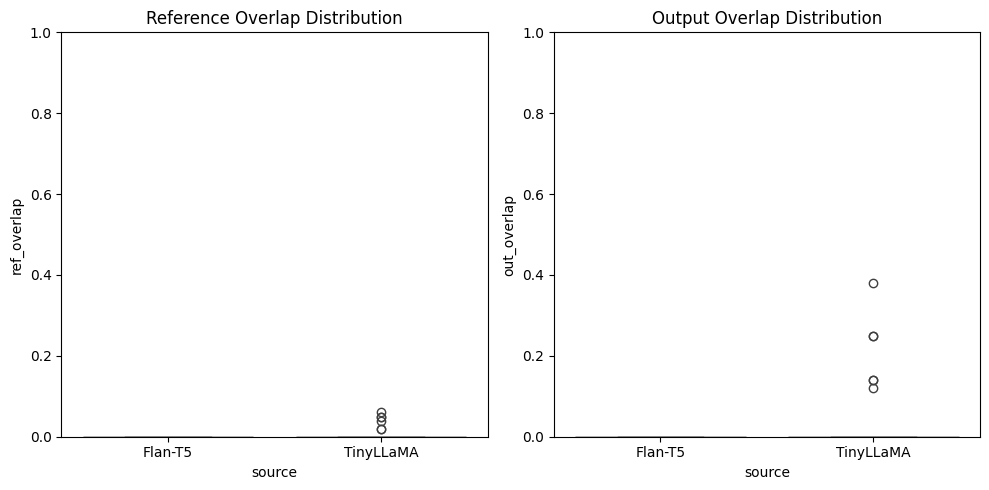

In [ ]:
plt.figure(figsize=(10,5))

# Reference Overlap
plt.subplot(1, 2, 1)
sns.boxplot(data=df_all, x="source", y="ref_overlap")
plt.title("Reference Overlap Distribution")
plt.ylim(0, 1)

# Output Overlap
plt.subplot(1, 2, 2)
sns.boxplot(data=df_all, x="source", y="out_overlap")
plt.title("Output Overlap Distribution")
plt.ylim(0, 1)

plt.tight_layout()
plt.show()


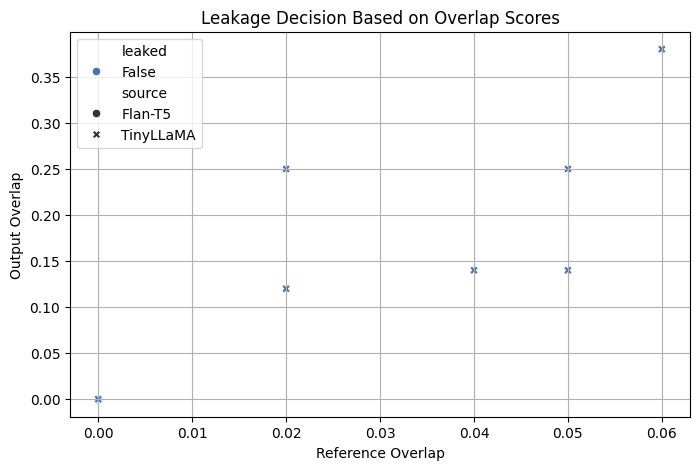

In [ ]:
plt.figure(figsize=(8, 5))
sns.scatterplot(
    data=df_all, x="ref_overlap", y="out_overlap", hue="leaked",
    style="source", palette="deep"
)
plt.title("Leakage Decision Based on Overlap Scores")
plt.xlabel("Reference Overlap")
plt.ylabel("Output Overlap")
plt.grid(True)
plt.show()


In [ ]:
summary = (
    df_all.groupby("source")["leaked"]
    .value_counts()
    .unstack()
    .reindex(columns=[False, True], fill_value=0)
)

summary.columns = ["Not Leaked", "Leaked"]
summary["Leak %"] = (summary["Leaked"] / summary.sum(axis=1) * 100).round(2)
summary


,Not Leaked,Leaked,Leak %
source,,,
Flan-T5,50,0,0.0
TinyLLaMA,30,0,0.0


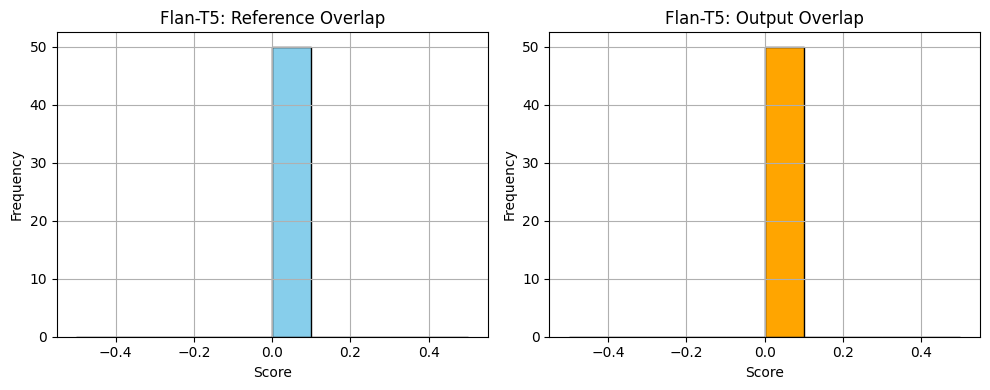

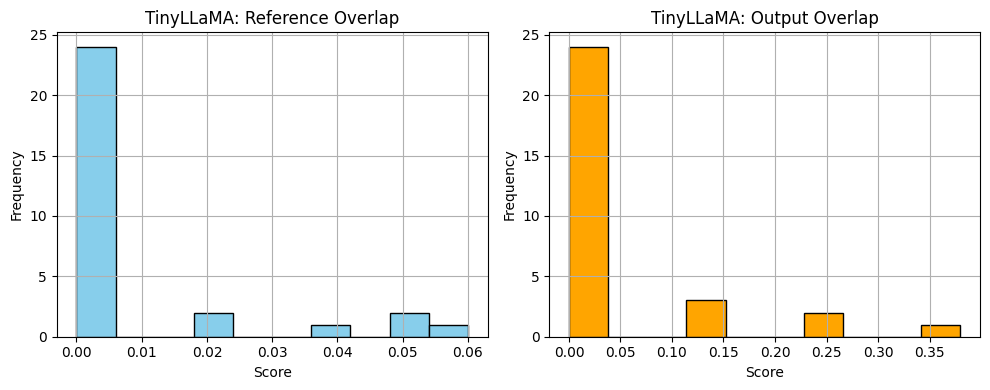

In [ ]:
import matplotlib.pyplot as plt

def plot_histogram(df, model_name):
    plt.figure(figsize=(10,4))

    plt.subplot(1, 2, 1)
    plt.hist(df["ref_overlap"], bins=10, color="skyblue", edgecolor="black")
    plt.title(f"{model_name}: Reference Overlap")
    plt.xlabel("Score")
    plt.ylabel("Frequency")
    plt.grid(True)

    plt.subplot(1, 2, 2)
    plt.hist(df["out_overlap"], bins=10, color="orange", edgecolor="black")
    plt.title(f"{model_name}: Output Overlap")
    plt.xlabel("Score")
    plt.ylabel("Frequency")
    plt.grid(True)

    plt.tight_layout()
    plt.show()

plot_histogram(df_flan, "Flan-T5")
plot_histogram(df_llama, "TinyLLaMA")


In [ ]:
# Top N most overlap cases (even if below threshold)
def show_top_n(df, column, n=5):
    top_n = df.sort_values(by=column, ascending=False).head(n)
    return top_n[["index", "model", "ref_overlap", "out_overlap", "prompt", "output"]]

# Show for Flan-T5
print("Top 5 Reference Overlaps (Flan-T5):")
display(show_top_n(df_flan, "ref_overlap"))

print("Top 5 Output Overlaps (Flan-T5):")
display(show_top_n(df_flan, "out_overlap"))

# Show for TinyLLaMA
print("Top 5 Reference Overlaps (TinyLLaMA):")
display(show_top_n(df_llama, "ref_overlap"))

print("Top 5 Output Overlaps (TinyLLaMA):")
display(show_top_n(df_llama, "out_overlap"))

Top 5 Reference Overlaps (Flan-T5):


,index,model,ref_overlap,out_overlap,prompt,output
0,0,flan-t5,0.0,0.0,Auch\tADV\tauch\nin\tAPPR\tin\ndiesem\tPDAT\td...,ADV also in APPR in diesem PDAT dies Jahr NN J...
1,1,flan-t5,0.0,0.0,Wir\tPPER\twir\nkönnen\tVMFIN\tkönnen\nnicht\t...,Wir PPER können VMFIN nicht PTKNEG nicht trete...
2,2,flan-t5,0.0,0.0,Diese\tPDAT\tdies\nunendlichen\tADJA\tunendlic...,Diese PDAT dies unendlichen ADJA unendlich Urt...
3,3,flan-t5,0.0,0.0,Hier\tADV\thier\nsollte\tVMFIN\tsollen\nunbedi...,Hier ADV hier sollte VMFIN unbedingt ADJD unbe...
4,4,flan-t5,0.0,0.0,Am\tAPPRART\tam\n1.\tADJA\t1.\n2.\tADJA\t2.\nu...,APPRART am 1. ADJA 1. 2. ADJA 2. und KON und .


Top 5 Output Overlaps (Flan-T5):


,index,model,ref_overlap,out_overlap,prompt,output
0,0,flan-t5,0.0,0.0,Auch\tADV\tauch\nin\tAPPR\tin\ndiesem\tPDAT\td...,ADV also in APPR in diesem PDAT dies Jahr NN J...
1,1,flan-t5,0.0,0.0,Wir\tPPER\twir\nkönnen\tVMFIN\tkönnen\nnicht\t...,Wir PPER können VMFIN nicht PTKNEG nicht trete...
2,2,flan-t5,0.0,0.0,Diese\tPDAT\tdies\nunendlichen\tADJA\tunendlic...,Diese PDAT dies unendlichen ADJA unendlich Urt...
3,3,flan-t5,0.0,0.0,Hier\tADV\thier\nsollte\tVMFIN\tsollen\nunbedi...,Hier ADV hier sollte VMFIN unbedingt ADJD unbe...
4,4,flan-t5,0.0,0.0,Am\tAPPRART\tam\n1.\tADJA\t1.\n2.\tADJA\t2.\nu...,APPRART am 1. ADJA 1. 2. ADJA 2. und KON und .


Top 5 Reference Overlaps (TinyLLaMA):


,index,model,ref_overlap,out_overlap,prompt,output
27,27,tinyllama-gguf,0.06,0.38,Ein\tART\teine\nist\tVAFIN\tsein\ndeshalb\tPAV...,POStagged German sentence:\nEin\tART\tein\nist...
8,8,tinyllama-gguf,0.05,0.25,Überdies\tADV\tüberdies\nhat\tVAFIN\thaben\nei...,ein\tART\tein\nSie\tPRT\tSie\nder\tART\tder\nS...
25,25,tinyllama-gguf,0.05,0.14,Gewerbliche\tADJA\tgewerblich\nKühlhäuser\tNN\...,der\tD\tder\nunter\tVMFIL\tunter\nKühlhäuser\t...
4,4,tinyllama-gguf,0.04,0.14,Die\tART\td\nBundesregierung\tNN\tBundesregier...,der\tART\tder\nSelbstvertrieb\tNN\tSelbstvertr...
6,6,tinyllama-gguf,0.02,0.25,Die\tART\td\nInformationsgesellschaft\tNN\tInf...,Die\tART\td\nInfoirmationsgesellsachtf\tNN\tIn...


Top 5 Output Overlaps (TinyLLaMA):


,index,model,ref_overlap,out_overlap,prompt,output
27,27,tinyllama-gguf,0.06,0.38,Ein\tART\teine\nist\tVAFIN\tsein\ndeshalb\tPAV...,POStagged German sentence:\nEin\tART\tein\nist...
8,8,tinyllama-gguf,0.05,0.25,Überdies\tADV\tüberdies\nhat\tVAFIN\thaben\nei...,ein\tART\tein\nSie\tPRT\tSie\nder\tART\tder\nS...
6,6,tinyllama-gguf,0.02,0.25,Die\tART\td\nInformationsgesellschaft\tNN\tInf...,Die\tART\td\nInfoirmationsgesellsachtf\tNN\tIn...
4,4,tinyllama-gguf,0.04,0.14,Die\tART\td\nBundesregierung\tNN\tBundesregier...,der\tART\tder\nSelbstvertrieb\tNN\tSelbstvertr...
25,25,tinyllama-gguf,0.05,0.14,Gewerbliche\tADJA\tgewerblich\nKühlhäuser\tNN\...,der\tD\tder\nunter\tVMFIL\tunter\nKühlhäuser\t...


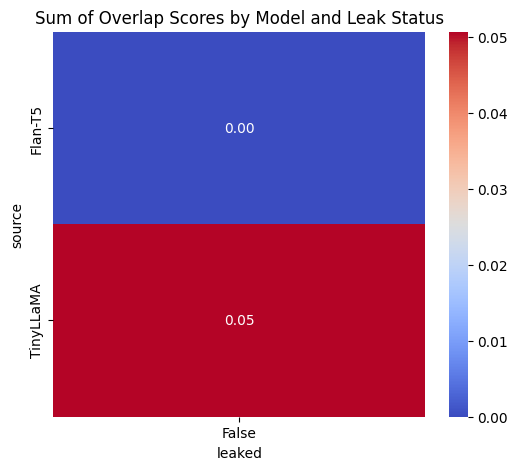

In [ ]:
import seaborn as sns

plt.figure(figsize=(6,5))
heat_data = df_all.copy()
heat_data["overlap_sum"] = heat_data["ref_overlap"] + heat_data["out_overlap"]

sns.heatmap(
    heat_data.pivot_table(values="overlap_sum", index="source", columns="leaked", fill_value=0),
    annot=True, fmt=".2f", cmap="coolwarm"
)
plt.title("Sum of Overlap Scores by Model and Leak Status")
plt.show()


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>